In [1]:
# import math
import random
import json
import math
import re
import torch
import torch.nn as nn
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
random.seed(42) # Let there be order among chaos
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Let there be a Tokenizer to translate strings to discrete symbols and back
with open('../model/Data/token_id.json', 'r', encoding='utf-8') as file:
    token_ids = json.load(file)
token_ids_map = {tok: i for i, tok in enumerate(token_ids)}
vocab_size = len(token_ids)

In [4]:
# Model parameters
n_embd = 64     # embedding dimension
n_head = 4      # number of attention heads
n_layer = 4     # number of layers
block_size = 96 # maximum sequence length
head_dim = n_embd // n_head # dimension of each head

In [5]:
# Helper function for RMSNorm
def rmsnorm(x):
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()

In [6]:
# Let there be a Transformer model
class TransformerLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn_wq = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wk = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wv = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_wo = nn.Linear(n_embd, n_embd, bias=False)
        self.mlp_fc1 = nn.Linear(n_embd, 4 * n_embd, bias=False)
        self.mlp_fc2 = nn.Linear(4 * n_embd, n_embd, bias=False)

    def forward(self, x):
        B, T, _ = x.shape

        # 1) Multi-head attention block
        x_residual = x
        x = rmsnorm(x)
        q = self.attn_wq(x).view(B, T, n_head, head_dim).transpose(1, 2)
        k = self.attn_wk(x).view(B, T, n_head, head_dim).transpose(1, 2)
        v = self.attn_wv(x).view(B, T, n_head, head_dim).transpose(1, 2)

        x_attn = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x_attn = x_attn.transpose(1, 2).contiguous().view(B, T, n_embd)
        x = self.attn_wo(x_attn) + x_residual

        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = F.relu(self.mlp_fc1(x))
        x = self.mlp_fc2(x)
        x = x + x_residual
        return x

    def forward_step(self, x, keys, values):

        # 1) Multi-head attention block
        x_residual = x
        x = rmsnorm(x)
        q = self.attn_wq(x)
        k = self.attn_wk(x)
        v = self.attn_wv(x)
        keys.append(k)
        values.append(v)
        x_attn = []
        for h in range(n_head):
            hs = slice(h * head_dim, (h + 1) * head_dim)
            q_h = q[hs]
            k_h = torch.stack([ki[hs] for ki in keys])
            v_h = torch.stack([vi[hs] for vi in values])
            attn_logits = (k_h @ q_h) / math.sqrt(head_dim)
            attn_weights = torch.softmax(attn_logits, dim=0)
            head_out = (v_h * attn_weights.unsqueeze(1)).sum(0)
            x_attn.append(head_out)
        x = self.attn_wo(torch.cat(x_attn)) + x_residual

        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = F.relu(self.mlp_fc1(x))
        x = self.mlp_fc2(x)
        x = x + x_residual
        return x

In [7]:
class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, n_embd)
        self.wpe = nn.Embedding(block_size, n_embd)
        self.layers = nn.ModuleList([TransformerLayer() for _ in range(n_layer)])
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight
        nn.init.normal_(self.wte.weight, std=0.08)
        nn.init.normal_(self.wpe.weight, std=0.08)

    def forward(self, token_ids_batch):
        B, T = token_ids_batch.shape
        pos = torch.arange(T, device=token_ids_batch.device)

        tok_emb = self.wte(token_ids_batch)
        pos_emb = self.wpe(pos)
        x = tok_emb + pos_emb
        x = rmsnorm(x)

        for layer in self.layers:
            x = layer(x)
        x = rmsnorm(x)
        return self.lm_head(x)

    def forward_step(self, token_id, pos_id, keys, values):
        tok_emb = self.wte.weight[token_id]
        pos_emb = self.wpe.weight[pos_id]
        x = tok_emb + pos_emb
        x = rmsnorm(x)

        for li, layer in enumerate(self.layers):
            x = layer.forward_step(x, keys[li], values[li])
        x = rmsnorm(x)
        return self.lm_head(x)

## Quantization Helper Functions

In [8]:
def fake_quantize(weight, bits, per_channel=True):
    quantized_weight = torch.zeros_like(weight)

    if per_channel:
        for i, row in enumerate(weight):
            scale = row.abs().max() / (2**(bits-1) - 1)
            q_weight = torch.round(row / scale)
            quantized_weight[i] = q_weight * scale
    else:
        scale = weight.abs().max() / (2**(bits-1) - 1)
        quantized_weight = torch.round(weight/scale) * scale
        
    return quantized_weight

In [9]:
def quantize_model(model, bits, per_channel=True):
    q_model = copy.deepcopy(model)
    with torch.no_grad():
        for name, param in q_model.named_parameters():
            param.copy_(fake_quantize(param.data, bits, per_channel))
    return q_model

In [10]:
def quantize_model_mixed(model, embed_bits=8, layer_bits=4, per_channel=True):
    q_model = copy.deepcopy(model)
    with torch.no_grad():
        for name, param in q_model.named_parameters():
            if 'wte' in name or 'wpe' in name:
                param.copy_(fake_quantize(param.data, embed_bits))
            else:
                param.copy_(fake_quantize(param.data, layer_bits))
    return q_model

## Evaluation Helper Functions

In [11]:
# Let there be an input dataset `docs`: list[str] of documents (e.g. a dataset of names)
docs = [l.strip() for l in open('../model/Data/data.txt', 'r', encoding='utf-8').read().strip().split('\n') if l.strip()] # list[str] of documents
random.shuffle(docs)
val_size = int(0.05 * len(docs))
val_docs = docs[:val_size]
docs = docs[val_size:]
print(f"train docs: {len(docs)}, val docs: {len(val_docs)}")

train docs: 65520, val docs: 3448


In [12]:
# Helper function to collate a batch of poems for training
def collate(batch_docs, block_size=block_size):
    pattern = r'<SEP>|<UNK>|.'
    PAD = token_ids_map['<EOS>']  # reuse EOS as pad id

    input_batch, target_batch = [], []
    for doc in batch_docs:
        doc_tokens = re.findall(pattern, doc)
        body_starts = doc_tokens.index('<SEP>')
        tokens = [token_ids_map['<BOS>']] + [token_ids_map[t] for t in doc_tokens] + [token_ids_map['<EOS>']]

        seq_in = tokens[:-1]
        seq_out = tokens[1:]

        # mask loss on title + <SEP>
        seq_out = [
            tok if i >= body_starts + 1 else -100
            for i, tok in enumerate(seq_out)
        ]

        pad_len = block_size - len(seq_in)
        seq_in = seq_in + [PAD] * pad_len
        seq_out = seq_out + [-100] * pad_len

        input_batch.append(seq_in)
        target_batch.append(seq_out)

    return torch.tensor(input_batch, device=device), torch.tensor(target_batch, device=device)

In [13]:
# Helper function to evaluate validation loss
@torch.no_grad()
def eval_val_loss(model, n_batches=10):
    model.eval()
    total_loss = 0.0
    batch_size = 64
    for _ in range(n_batches):
        batch_docs = random.sample(val_docs, min(batch_size, len(val_docs)))
        input_ids, targets = collate(batch_docs)
        logits = model(input_ids)
        loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1), ignore_index=-100)
        total_loss += loss.item()
    model.train()
    return total_loss / n_batches

## Quantized Models

In [14]:
# Load best model
model_f32 = GPT().to(device)
model_f32.load_state_dict(torch.load('../model/Data/best_model.pt', map_location=device))
model_f32.eval()

model_int8 = quantize_model(model_f32, bits=8)
model_int4 = quantize_model(model_f32, bits=4)

model_int8_per_tensor = quantize_model(model_f32, bits=8, per_channel=False)
model_int4_per_tensor = quantize_model(model_f32, bits=4, per_channel=False)

model_mixed = quantize_model_mixed(model_f32, embed_bits=8, layer_bits=4)

### Evaluating Validation Loss

In [17]:
models = [model_f32, model_int8, model_int4,
          model_int8_per_tensor, model_int4_per_tensor, model_mixed]
names = ["float32 \t", "INT8 (per-channel)", "INT4 (per-channel)",
         "INT8 (per-tensor)", "INT4 (per-tensor)", "Mixed INT8/INT4"]
val_loss_table = {}

for name, model in zip(names, models):
    val_loss = eval_val_loss(model)
    print(f"{name} \t val_loss={val_loss:.4f}")
    val_loss_table[name] = val_loss

float32 	 	 val_loss=4.8990
INT8 (per-channel) 	 val_loss=4.9069
INT4 (per-channel) 	 val_loss=5.1096
INT8 (per-tensor) 	 val_loss=4.9032
INT4 (per-tensor) 	 val_loss=8.3511
Mixed INT8/INT4 	 val_loss=5.0610


### Evaluating Memory Cost

In [18]:
# float32
float32_bits = 0
for name, param in model_f32.named_parameters():
    n = param.numel()
    float32_bits += n * 32

# INT8 per channel
int8_bits = 0
for name, param in model_int8.named_parameters():
    n = param.numel()
    int8_bits += n * 8

# Mixed INT8/INT4
mixed_bits = 0
for name, param in model_mixed.named_parameters():
    n = param.numel()
    if 'wte' in name or 'wpe' in name:
        mixed_bits += n * 8
    else:
        mixed_bits += n * 4

# INT4 per channel
int4_bits = 0
for name, param in model_int4.named_parameters():
    n = param.numel()
    int4_bits += n * 4

print(f"float32: {float32_bits/8/1024:.2f} KB")
print(f"INT8:    {int8_bits/8/1024:.2f} KB")
print(f"Mixed:   {mixed_bits/8/1024:.2f} KB")
print(f"INT4:    {int4_bits/8/1024:.2f} KB")

float32: 1543.25 KB
INT8:    385.81 KB
Mixed:   289.81 KB
INT4:    192.91 KB


### Plot Performance vs. Resource Cost

In [19]:
configs = ['float32', 'int8', 'mixed', 'int4']
memory_data = [bits/8/1024 for bits in [float32_bits, int8_bits, mixed_bits, int4_bits]]
val_loss_data = [val_loss_table["float32 \t"], val_loss_table["INT8 (per-channel)"],
                 val_loss_table["Mixed INT8/INT4"], val_loss_table["INT4 (per-channel)"]]

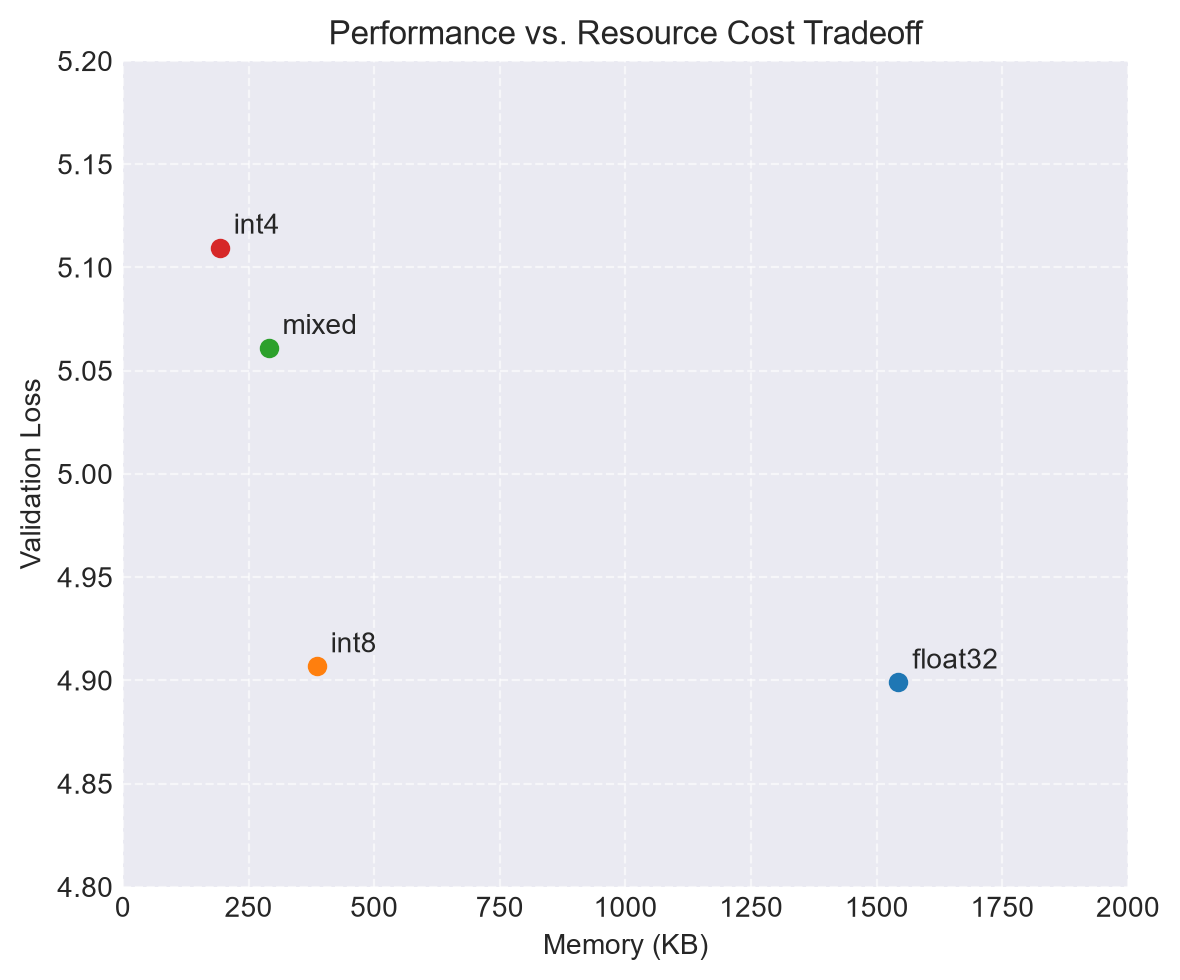

In [22]:
# Light plot
plt.figure(figsize=(6,5), dpi=200)

for i in range(len(memory_data)):
    plt.scatter(memory_data[i], val_loss_data[i])

for x, y, label in zip(memory_data, val_loss_data, configs):
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(5,5))
    
plt.xlabel('Memory (KB)')
plt.ylabel('Validation Loss')
plt.title('Performance vs. Resource Cost Tradeoff')
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
plt.xlim([0, 2000])
plt.ylim([4.8, 5.2])
plt.tight_layout()
plt.style.use('seaborn-v0_8-dark')
plt.savefig('quantization_light.png', dpi=300, bbox_inches='tight')
plt.show()

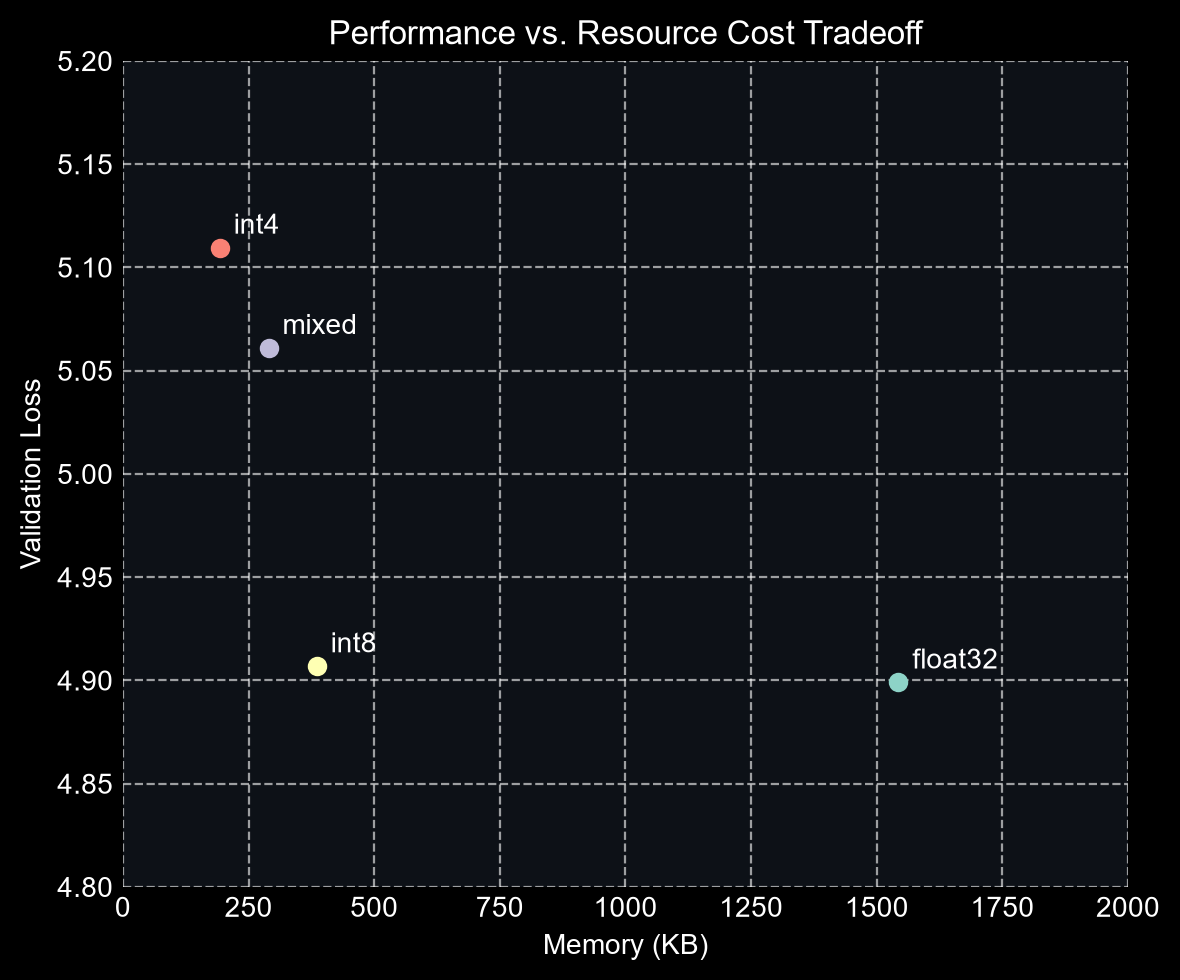

In [27]:
# dark plot
plt.style.use('dark_background')
plt.figure(figsize=(6,5), dpi=200)

ax = plt.gca()
ax.set_facecolor('#0d1117')

for i in range(len(memory_data)):
    plt.scatter(memory_data[i], val_loss_data[i])

for x, y, label in zip(memory_data, val_loss_data, configs):
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(5,5))
    
plt.xlabel('Memory (KB)')
plt.ylabel('Validation Loss')
plt.title('Performance vs. Resource Cost Tradeoff')
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
plt.xlim([0, 2000])
plt.ylim([4.8, 5.2])
plt.tight_layout()
plt.style.use('seaborn-v0_8-dark')
plt.savefig('quantization_dark.png', dpi=300, bbox_inches='tight')
plt.show()

### Dump INT8 Model Weights to File

In [44]:
def real_quantize_int8(weight):
    scales = torch.zeros(weight.shape[0])
    q_weight = torch.zeros_like(weight, dtype=torch.int8)
    for i, row in enumerate(weight):
        scale = row.abs().max() / (2 ** 8 - 1)
        scales[i] = scale
        q_weight[i] = torch.round(row / scale).to(torch.int8)
    return q_weight, scales

In [45]:
def dump_to_mem_file(tensor, filepath):
    flat = tensor.flatten()
    with open(filepath, 'w') as file:
        for val in flat.tolist():
            hex_val = format(val & 0xFF, '02x') # two's complement
            file.write(hex_val + '\n')

In [46]:
# dump weights of each tensor in model
weight_dirs = {}
for name, param in model_f32.named_parameters():
    q_weight, scales = real_quantize_int8(param.data)
    dump_to_mem_file(q_weight, "./Data/" + name + ".mem")
    weight_dirs[name] = scales.tolist()

with open("./Data/scales.json", 'w') as file:
    json.dump(weight_dirs, file, indent=4)

### Generate Some Poems with the Quantized Models

In [34]:
# Load rhyme table, tone table, and poem templates
with open('../model/Data/rhyme_table.json', 'r', encoding='utf-8') as file:
    rhyme_table = json.load(file)

with open('../model/Data/tone_table.json', 'r', encoding='utf-8') as file:
    tone_table = json.load(file)

with open('../model/Data/templates.json', 'r', encoding='utf-8') as file:
    templates = json.load(file)

rhyme_dict = {}
for character, rhyme_group in rhyme_table.items():
    rhyme_dict.setdefault(rhyme_group, []).append(character)

tone_dict = {}
for character, tone in tone_table.items():
    tone_dict.setdefault(tone, []).append(character)

In [35]:
# Helper function to enforce tone and rhyme requirements
def apply_constraints(logits, tone, rhyme_required, rhyme_group, prev_rhymes):
    mask = torch.zeros_like(logits)

    # check tone
    if tone == "平":
        ze_chars = tone_dict['仄']
        ze_token_ids = [token_ids_map[char] for char in ze_chars]
        mask[ze_token_ids] = float('-inf')
    elif tone == '仄':
        ping_chars = tone_dict['平']
        ping_token_ids = [token_ids_map[char] for char in ping_chars]
        mask[ping_token_ids] = float('-inf')

    # check rhyme
    if rhyme_required:
        non_rhyme_chars = [
            character for rhyme_groups, characters in rhyme_dict.items()
            if rhyme_groups != rhyme_group
            for character in characters
        ]
        non_rhyme_token_ids = [token_ids_map[char] for char in non_rhyme_chars]
        mask[non_rhyme_token_ids] = float('-inf')

        # cannot rhyme on the same character
        if len(prev_rhymes) > 0:
            prev_rhyme_token_ids = [token_ids_map[char] for char in prev_rhymes]
            mask[prev_rhyme_token_ids] = float('-inf')

    return mask

In [37]:
# Inference - generate new poems
title = str(input("Enter a title for the poem: "))
prefix = [token_ids_map['<BOS>']] + [token_ids_map[c] for c in title] + [token_ids_map['<SEP>']]

temperature = 0.6 # in (0, 1], control the "creativity" of generated text, low to high
print("\n--- inference (new, hallucinated poems) ---")
print("Title: " + title)
print("")

model_list = [model_f32, model_int8, model_mixed, model_int4]

with torch.no_grad():
    for i, model in enumerate(model_list):
        keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]

        # Prime KV cache with title — run forward but don't sample
        for pos_id, token_id in enumerate(prefix):
            logits = model.forward_step(token_id, pos_id, keys, values)

        print("Model: " + configs[i])
        sample = []
        rhyme_group = None
        rhyme_required = False
        prev_rhymes = []
        generated_ids = []
        repetition_penalty = 1.3

        # random template
        template_num = random.randint(1, 4)
        template = templates["template" + str(template_num)]

        for pos_id in range(block_size - len(prefix)):

            # ban unknown characters and invalid tokens
            logits[token_ids_map['<UNK>']] = float('-inf')
            logits[token_ids_map['<BOS>']] = float('-inf')
            logits[token_ids_map['<SEP>']] = float('-inf')

            # repetition penalty
            if generated_ids:
                for tid in generated_ids:
                    if logits[tid] > 0:
                        logits[tid] /= repetition_penalty
                    else:
                        logits[tid] *= repetition_penalty

            # check if rhyme required
            if (pos_id % 14 == 13 and rhyme_group != None):
                rhyme_required = True
            else:
                rhyme_required = False

            mask = apply_constraints(logits, template[pos_id % 56], rhyme_required, rhyme_group, prev_rhymes)
            probs = torch.softmax((logits + mask) / temperature, dim=0)
            token_id = torch.multinomial(probs, 1).item()

            # check if poem ends
            if token_id == token_ids_map['<EOS>']:
                break

            character = token_ids[token_id]
            sample.append(character)
            print(character, end="")

            if token_id not in generated_ids:
                generated_ids.append(token_id)

            if (rhyme_required):
                prev_rhymes.append(character)

            # confirm rhyme group if character is the first in poem that rhymes
            if (template_num in [1, 3] and pos_id % 14 == 13) or (template_num in [2, 4] and pos_id % 14 == 6):
                if rhyme_group == None:
                    rhyme_group = rhyme_table[character]
                    prev_rhymes.append(character)

            # add punctuations
            if (pos_id % 14 == 6):
                print("，", end="")
            elif (pos_id % 14 == 13):
                print("。")

            logits = model.forward_step(token_id, pos_id + len(prefix), keys, values)
        print()


--- inference (new, hallucinated poems) ---
Title: 咏柳

Model: float32
海门亭上望人家，莫笑清风出翠沙。
一点暗迷朱碧水，几痕长断白青霞。
花边花落如何事，柳外溪高似是夸。
更看林峦皆秀色，欲归无路不平涯。

Model: int8
东水西风掠碧波，春光一片满天河。
飞鸢浸水寒生响，飞兔浮云上有何。
红白岂知谁识量，翠娥相对独留歌。
开边把酒谁堪赠，诗就新编付一哦。

Model: mixed
几番春色又初晴，候节年来雨未明。
不但中寒催舞日，更堪南北得秋声。
彤墀引领迎环帝，宝髻呈祥拥紫城。
忆带春风歌姓字，更须吹烛下金京。

Model: int4
小园芳卉共黄花，东上春光惹画蛇。
含笑渐繁飞玉树，乱红未著落金沙。
朱栏谁记穿枝去，紫禁新成送酒家。
野客不知人底事，九朝御史一时夸。

